
Running for v_mer = 7 m/s
stab_par: 0.021622217826402154

Running for v_mer = 10 m/s
stab_par: 0.021622217826402154

Running for v_mer = 15 m/s
stab_par: 0.021622217826402154

Running for v_mer = 20 m/s
stab_par: 0.021622217826402154

Running for v_mer = 25 m/s
stab_par: 0.021622217826402154


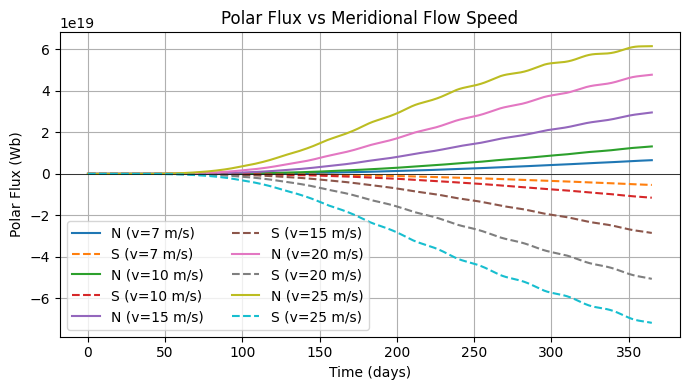

In [1]:
import numpy as np
import matplotlib.pyplot as plt

deg2rad = np.pi / 180.0
rad2deg = 180.0 / np.pi

R = 6.96e8
dt = 0.001

# -------------------------------
# PARAMETER SWEEP (MERIDIONAL FLOW)
# -------------------------------
v_mer_values = [7, 10, 15, 20, 25]

polar_flux_all_n = []
polar_flux_all_s = []
time_axis = None

# -------------------------------
# FIXED PARAMETERS
# -------------------------------
diff_const = 600
alpha = diff_const *1e6 * 24*60*60

dphi = 2*deg2rad
dtheta1_d = 2*3
dtheta2_d = 3
dtheta3_d = 2

tot_time = 365
N_steps = int(tot_time / dt)

save = 100
N_save = int(N_steps / save)+1
N_phi = int(2*np.pi/ dphi)

omega_max_deg = 13.38
omega_max = omega_max_deg*deg2rad

# -------------------------------
# GRID
# -------------------------------
theta_1n = np.arange(5, 30, dtheta1_d)
theta_2n = np.arange(30, 60, dtheta2_d)
theta_3 = np.arange(60, 120, dtheta3_d)
theta_2s = np.arange(120, 150, dtheta2_d)
theta_1s = np.arange(150, 180 - 5, dtheta1_d)

N_theta = (len(theta_1n) + len(theta_2n) + len(theta_3) + len(theta_2s) + len(theta_1s))
theta_deg = np.concatenate((theta_1n, theta_2n, theta_3, theta_2s, theta_1s))
theta = theta_deg * deg2rad

dtheta1 = dtheta1_d * deg2rad
dtheta2 = dtheta2_d * deg2rad
dtheta3 = dtheta3_d * deg2rad

phi = np.arange(0, 2 * np.pi, dphi)
Phi, Theta = np.meshgrid(phi, theta)

# -------------------------------
# INITIAL FIELD (BMRs)
# -------------------------------
sigma_t = 5 * deg2rad
sigma_p = 7.07 * deg2rad 

T_plus_1 = 3000*np.exp(-0.5*(((Theta - (9*np.pi/24))/sigma_t)**2+((Phi - np.pi*(6/6))/sigma_p)**2))
T_minus_1 = -3000*np.exp(-0.5*(((Theta - (10.5*np.pi/24))/sigma_t)**2+((Phi - np.pi*(7/6))/sigma_p)**2))
T_plus_2 = 3000*np.exp(-0.5*(((Theta - (13.5*np.pi/24))/sigma_t)**2+((Phi - np.pi*(7/6))/sigma_p)**2))
T_minus_2 = -3000*np.exp(-0.5*(((Theta - (15*np.pi/24))/sigma_t)**2+((Phi - np.pi*(6/6))/sigma_p)**2))

# -------------------------------
# GEOMETRY
# -------------------------------
dtheta_rad = np.zeros(N_theta)
dtheta_rad[:len(theta_1n)] = dtheta1
dtheta_rad[len(theta_1n):len(theta_1n) + len(theta_2n)] = dtheta2
dtheta_rad[len(theta_1n) + len(theta_2n):len(theta_1n) + len(theta_2n) + len(theta_3)] = dtheta3
dtheta_rad[len(theta_1n) + len(theta_2n) + len(theta_3):len(theta_1n) + len(theta_2n) + len(theta_3) + len(theta_2s)] = dtheta2
dtheta_rad[len(theta_1n) + len(theta_2n) + len(theta_3) + len(theta_2s):] = dtheta1

omega = omega_max - (2.3 * (np.cos(theta))**2 - 1.62*(np.cos(theta))**4) * deg2rad

cot = 1/np.tan(theta)
sin2 = (np.sin(theta))**2
cos = np.cos(theta)
sin = np.sin(theta)

north_cap = theta_deg <= 30
south_cap = theta_deg >= 150

element_area = (R**2) * sin * dtheta_rad * dphi

# ===============================
# PARAMETER SWEEP LOOP
# ===============================
for v_mer_ms in v_mer_values:

    print(f"\nRunning for v_mer = {v_mer_ms} m/s")

    v_mer_max = v_mer_ms * 24*60*60

    # stability condition
    delta_x = R*np.min(np.sin(theta))*dphi
    delta_y = R*dtheta3

    stab_par = min((min(delta_x**2,delta_y**2))/(4*alpha), delta_y/v_mer_max, dphi/omega_max)
    print(f"stab_par: {stab_par}")
    assert dt <= stab_par, "Stability condition violated!"

    # -------------------------------
    # RESET FIELD
    # -------------------------------
    T = (T_plus_1 + T_minus_1 + T_plus_2 + T_minus_2).T
    T_new = np.zeros_like(T)

    flux_north = []
    flux_south = []
    time_days = []

    accum_bottom = np.zeros(N_phi)
    accum_top = np.zeros(N_phi)

    # recompute meridional flow
    col = theta*rad2deg - 90
    v_mer = np.where(np.abs(col)<=75, v_mer_max * np.sin(np.pi * col / 75), 0)

    # ===============================
    # TIME LOOP
    # ===============================
    for n in range(1, N_steps + 1):

        t_days = n * dt

        i_sl = slice(1, -1)
        j_sl = slice(1, -1)

        Tc   = T[i_sl, j_sl]
        T_ip = T[2:,  j_sl]
        T_im = T[:-2, j_sl]
        T_jp = T[i_sl, 2:]
        T_jm = T[i_sl, :-2]

        dth     = dtheta_rad[1:-1]
        inv_dth = 1.0 / dth
        inv_dth2= inv_dth**2

        sin_i   = sin[1:-1]
        sin2_i  = sin2[1:-1]
        cot_i   = cot[1:-1]

        sin_ph   = sin[2:]
        sin_mh   = sin[:-2]
        omg_c    = omega[1:-1]

        v_ph     = 0.5*(v_mer[1:-1] + v_mer[2:])
        v_mh     = 0.5*(v_mer[:-2]  + v_mer[1:-1])

        eps = 1e-1
        sin2_i_safe = np.maximum(sin2_i, eps**2)
        cot_i_safe  = np.maximum(cot_i, eps)

        d2T_dtheta = (T_jp - 2.0 * Tc + T_jm) * inv_dth2
        cot_term   = cot_i_safe * ((Tc - T_jm) * inv_dth)
        d2T_dphi   = (T_ip - 2.0 * Tc + T_im) / (dphi**2)

        diffusion = (alpha / (R**2)) * dt * (d2T_dtheta + cot_term + (d2T_dphi / sin2_i_safe))

        div_phi = omg_c * (Tc - T_im) / dphi

        vph_pos = v_ph >= 0
        vmh_pos = v_mh >= 0

        T_up_ph = np.where(vph_pos, Tc, T_jp)
        Fth_ph  = v_ph * T_up_ph

        T_up_mh = np.where(vmh_pos, T_jm, Tc)
        Fth_mh  = v_mh * T_up_mh

        div_theta = (sin_ph * Fth_ph - sin_mh * Fth_mh) / dth
        div_theta = div_theta / (R * np.maximum(sin_i, 1e-8))

        advection = -div_phi - div_theta

        T_new[i_sl, j_sl] = Tc + diffusion + dt * advection

        # boundary conditions
        T_new[0,   1:-1] = T_new[-2, 1:-1]
        T_new[-1,  1:-1] = T_new[1,  1:-1]

        accum_bottom += T_new[:, 1]
        accum_top    += T_new[:, -2]

        T_new[1:-1, 0]  = T_new[1:-1, 1]
        T_new[1:-1, -1] = T_new[1:-1, -2]

        T = T_new.copy()

        if (n % 100) == 0:
            flux_n = np.sum(T[:,north_cap] * element_area[north_cap][None,:])
            flux_s = np.sum(T[:,south_cap] * element_area[south_cap][None,:])

            flux_north.append(flux_n)
            flux_south.append(flux_s)
            time_days.append(t_days)

    polar_flux_all_n.append(flux_north)
    polar_flux_all_s.append(flux_south)

    if time_axis is None:
        time_axis = time_days

# ===============================
# FINAL PLOT
# ===============================
plt.figure(figsize=(7,4))

for i, v in enumerate(v_mer_values):
    plt.plot(time_axis, polar_flux_all_n[i], label=f"N (v={v} m/s)")
    plt.plot(time_axis, polar_flux_all_s[i], linestyle='--', label=f"S (v={v} m/s)")

plt.axhline(0.0, color='k', lw=0.5)
plt.xlabel("Time (days)")
plt.ylabel("Polar Flux (Wb)")
plt.title("Polar Flux vs Meridional Flow Speed")
plt.legend(ncol=2)
plt.grid()
plt.tight_layout()
plt.show()